# (IIP314W-2) [2026-T2] OPTIMIZACIÓN APLICADA A NEGOCIOS
## Ayudantía 8 — Pauta: Repaso integrador — modelamiento, dualidad y KKT

---

**Profesor:** Ing. Rodrigo Trigo Vilches

**Ayudante:** Lic. Vicente Ramírez

**Fecha:** 12 de agosto de 2026

**Universidad del Desarrollo**

---

## Objetivos

Esta es la **última ayudantía del curso**, y es deliberadamente **integradora**: recorre en un solo hilo todo lo que vimos, sobre un mismo negocio.

- Formular un modelo **entero-mixto** que combine **restricciones de todos los tipos**: igualdades de balance, requerimientos mínimos ($\ge$), disponibilidades ($\le$), un **indicador binario de dos lados** (lote mínimo + costo fijo) y cotas de demanda.
- Construir el **dual** de un LP cuyo primal tiene restricciones $\le$ **y** $\ge$, y leer correctamente los **signos** de las variables duales.
- Verificar **dualidad fuerte** y **holguras complementarias**, e interpretar cada precio sombra —incluido uno **negativo**— en términos de negocio.
- Escribir las **condiciones KKT** y comprobar que, para un LP, **KKT no es otra cosa que la dualidad**: la estacionariedad *es* la factibilidad dual, y la holgura complementaria *es* la misma de siempre. Los **multiplicadores $\mu_i$ son los precios sombra**.
- Resolver un problema **no lineal** por **KKT enumerando casos**, verificar la **concavidad** que garantiza que el punto es óptimo **global**, y comprobar que $\mu_i=\partial f^*/\partial b_i$ **también** en el caso no lineal.

> **Conexión con las clases.** En la **Clase 29 (Repaso)** el profesor cerró con **Lagrange** y **KKT** en programación no lineal: convexidad como condición de suficiencia, el Lagrangiano, y la resolución **revisando todas las combinaciones de restricciones activas e inactivas**. En la **Ayudantía 6** construimos el dual y leímos los precios sombra en el tableau; en la **Ayudantía 7** los usamos para análisis de sensibilidad. Esta ayudantía **cierra el círculo**: muestra que dualidad, precios sombra y holgura complementaria son **casos particulares de KKT**.

## Repaso

### 0.1 Un catálogo de restricciones

Casi todo modelo de negocio se arma con cinco o seis piezas. Conviene tenerlas identificadas por **tipo**, porque el tipo determina el signo de su variable dual.

| Estructura | Forma | Tipo | Ejemplo |
|:--|:--|:--:|:--|
| **Balance de masa** | $p_i=\sum_k x_{ki}$ | $=$ | lo producido es la suma de los insumos que entraron |
| **Requerimiento de calidad** | $\sum_k \pi_k x_{ki}\;\ge\;\pi^{\min}_i\,p_i$ | $\ge$ | la mezcla debe tener al menos $38\%$ de proteína |
| **Disponibilidad de recurso** | $\sum_i x_{ki}\le S_k$ | $\le$ | no hay más de $150$ t de harina de pescado al mes |
| **Capacidad** | $\sum_i p_i\le C$ | $\le$ | la extrusora procesa $1.100$ t/mes |
| **Balance de inventario** | $r_{it}=r_{i,t-1}+p_{it}-v_{it}$ | $=$ | lo que queda es lo que había, más lo que entró, menos lo que salió |
| **Indicador de dos lados** | $L^{\min}y_i\le p_i\le M\,y_i$ | binaria | *"o no se produce, o se produce al menos un lote"* |
| **Cotas** | $\underline d_i\le v_i\le \bar d_i$ | $lb/ub$ | compromiso contractual y demanda máxima |

**Sobre el requerimiento de calidad.** La tentación es escribirlo como cociente,
$$\frac{\sum_k \pi_k x_{ki}}{\sum_k x_{ki}}\ge \pi^{\min}_i,$$
que **no es lineal** y está indefinido si no se produce nada. Se **multiplica cruzado** y queda lineal. Es la misma maniobra de las proporciones de mezcla de la Ayudantía 7.

**Sobre el indicador de dos lados.** Es la pieza nueva de hoy. Modela *"o cero, o al menos $L^{\min}$"* —una **disyunción**, que es intrínsecamente no convexa y por eso **necesita** una binaria:

$$\boxed{\;L^{\min}\,y_i\;\le\;p_i\;\le\;M\,y_i\;}\qquad y_i\in\{0,1\}$$

- $y_i=0\;\Rightarrow\;0\le p_i\le 0$: la línea está **apagada**.
- $y_i=1\;\Rightarrow\;L^{\min}\le p_i\le M$: si se enciende, hay que hacer **al menos un lote**.

El costo fijo $F\,y_i$ en la objetivo es lo que hace que apagar la línea sea a veces lo correcto. Y como siempre: **$M$ debe ser la cota válida más chica** (aquí, la capacidad de la extrusora), no $10^9$.

### 0.2 El dual cuando hay restricciones de varios tipos

La regla de la Ayudantía 6 servía para el caso "todas $\le$". La versión general para un **primal de maximización** es:

| Primal ($\max\;c^\top x$) | Dual ($\min\;b^\top y$) |
|:--|:--|
| restricción $i$ de tipo $\;\le b_i$ | $y_i\ \ge 0$ |
| restricción $i$ de tipo $\;\ge b_i$ | $y_i\ \le 0$ |
| restricción $i$ de tipo $\;= b_i$ | $y_i$ **libre** |
| variable $x_j\ge0$ | restricción dual $j$ de tipo $\ \ge c_j$ |
| variable $x_j$ libre | restricción dual $j$ de tipo $\ = c_j$ |

**La regla mnemotécnica y su sentido económico.** En un máximo, **relajar un techo nunca puede empeorar** el óptimo $\Rightarrow y_i\ge0$ para las $\le$. En cambio, **subir un piso nunca puede mejorarlo** $\Rightarrow y_i\le0$ para las $\ge$: un compromiso mínimo más exigente es una **obligación**, y su precio sombra mide **cuánto cuesta**, no cuánto vale.

Una restricción $\ge$ siempre se puede llevar a $\le$ multiplicando por $-1$ ($a_i^\top x\ge b_i\iff -a_i^\top x\le -b_i$); el multiplicador $\mu_i\ge0$ de la forma $\le$ y el precio sombra $y_i$ del problema original cumplen $y_i=-\mu_i$. **Es el mismo número con distinto signo**, y hay que ser explícito sobre cuál se está reportando. Gurobi reporta siempre $y_i=\partial z^*/\partial b_i$ sobre la restricción **tal como fue escrita**.

**Dualidad débil / fuerte y holguras complementarias** (igual que en la Ayudantía 6):

$$c^\top x\le b^\top y\ \ \forall\text{ par factible},\qquad c^\top x^*=b^\top y^*,\qquad
\underbrace{y_i^*\,\big(b_i-a_i^\top x^*\big)=0}_{\text{por restricción}},\qquad
\underbrace{x_j^*\,\big(a_j^\top y^*-c_j\big)=0}_{\text{por variable}}.$$

### 0.3 KKT: la teoría que contiene a todo lo anterior

Las condiciones de **Karush–Kuhn–Tucker** son las condiciones de optimalidad de **cualquier** problema con restricciones, lineal o no. Para un problema de **maximización** escrito con todas las restricciones en forma $g_i(x)\le0$:

$$\max_x\; f(x)\qquad\text{s.a.}\quad g_i(x)\le0\ \ (i=1,\dots,m)$$

el **Lagrangiano** es

$$\boxed{\;\mathcal L(x,\mu)=f(x)-\sum_{i=1}^m \mu_i\,g_i(x)\;}$$

y las condiciones KKT en $(x^*,\mu^*)$ son cuatro:

| # | Condición | Forma | Qué dice |
|:--:|:--|:--|:--|
| 1 | **Estacionariedad** | $\nabla f(x^*)=\displaystyle\sum_i \mu_i^*\,\nabla g_i(x^*)$ | el gradiente de la ganancia es una combinación de los gradientes de las restricciones que topan |
| 2 | **Factibilidad primal** | $g_i(x^*)\le0\ \ \forall i$ | la solución es factible |
| 3 | **Factibilidad dual** | $\mu_i^*\ge0\ \ \forall i$ | los multiplicadores no son negativos |
| 4 | **Holgura complementaria** | $\mu_i^*\,g_i(x^*)=0\ \ \forall i$ | o la restricción está **activa**, o su multiplicador es **cero** |

Y el resultado que da sentido económico a todo:

$$\boxed{\;\mu_i^*=\frac{\partial f^*}{\partial b_i}\;}$$

**el multiplicador de KKT *es* el precio sombra.** La condición 4 es **exactamente** la holgura complementaria de la Ayudantía 6: *si sobra recurso, no pago por más; si pago por más, es porque está agotado.*

> **Cuándo sirven.** KKT es **necesaria** bajo una **cualificación de restricciones** (basta que las restricciones sean lineales, o la condición de Slater: que exista un punto **estrictamente** factible). Es **suficiente** —y entrega el óptimo **global**— cuando el problema es **cóncavo** (maximizar $f$ cóncava sobre un conjunto convexo). Un LP cumple ambas cosas siempre.

**Cómo se resuelve a mano.** Como en la Clase 29: se **enumeran las combinaciones de restricciones activas e inactivas**. Para cada combinación se impone $\mu_i=0$ en las inactivas y $g_i(x)=0$ en las activas, se resuelve el sistema, y se **descarta** el caso si aparece $\mu_i<0$, si $x$ viola alguna restricción, o si el sistema es incompatible. Con $m$ restricciones son $2^m$ casos, pero la mayoría se cae en una línea.

### 0.4 KKT aplicado a un LP: **es la dualidad**

Tomemos el LP $\;\max\,c^\top x\;$ s.a. $\;Ax\le b,\;x\ge0$. Las restricciones son $g_i(x)=a_i^\top x-b_i\le0$ y $g^{neg}_j(x)=-x_j\le0$, con multiplicadores $\mu_i$ y $\sigma_j$. El Lagrangiano es

$$\mathcal L=c^\top x-\sum_i\mu_i\,(a_i^\top x-b_i)+\sum_j\sigma_j x_j,$$

y la estacionariedad respecto de $x_j$ da

$$c_j-\sum_i \mu_i a_{ij}+\sigma_j=0 \;\;\Longleftrightarrow\;\; \sum_i \mu_i a_{ij}=c_j+\sigma_j\;\ge\;c_j\quad(\text{pues }\sigma_j\ge0).$$

Es decir $A^\top\mu\ge c$ con $\mu\ge0$: **la factibilidad del dual**. Y la holgura complementaria de $\sigma_j$ dice $\sigma_j x_j=0$, o sea $x_j>0\Rightarrow\sigma_j=0\Rightarrow$ la restricción dual $j$ está **activa**. La tabla completa:

| KKT | Programación lineal |
|:--|:--|
| Estacionariedad | **Factibilidad dual**: $A^\top y\ge c$ |
| Factibilidad primal | $Ax\le b,\;x\ge0$ |
| $\mu_i\ge0$ | $y_i\ge0$ para las restricciones $\le$ |
| Holgura complementaria en $g_i$ | $y_i\,(b_i-a_i^\top x)=0$ |
| Holgura complementaria en $-x_j\le0$ | $x_j\,(a_j^\top y-c_j)=0$ |
| $\mu_i=\partial f^*/\partial b_i$ | **precio sombra** |

$$\boxed{\;\mu^*=y^*\;}$$

**Los multiplicadores de KKT y las variables duales son el mismo objeto.** Todo lo que hicimos con el tableau en la Ayudantía 6 era KKT sin decirlo. La diferencia es que **KKT sigue funcionando cuando el problema deja de ser lineal**, que es lo que veremos en el Ejercicio 3.

---

# Ejercicio 1 — Planta de alimento para salmones "AquaNutrí Chiloé"

### Contexto

**AquaNutrí Chiloé** fabrica alimento extruido para salmonicultura y debe planificar los próximos **tres meses**. Produce dos formulaciones:

- **Engorda** (EN), el producto de volumen, que va a las balsas-jaula de engorda;
- **Smolt** (SM), un alimento de alta proteína para peces jóvenes en agua dulce, más caro y más rentable.

Ambos se fabrican mezclando tres insumos: **harina de pescado** (HP), **concentrado de soya** (SOY) y **harina de trigo** (TRI). Cada insumo tiene un **contenido proteico** $\pi_k$ y un costo $c_k$ por tonelada; cada formulación exige un **mínimo de proteína** $\pi^{\min}_i$. La harina de pescado es la única con proteína suficientemente alta para el Smolt, y es también la **escasa**: hay un cupo mensual $S_{\text{HP},t}$ por la cuota de pesca.

La **extrusora** es una sola línea y procesa hasta $C$ toneladas al mes, sumando ambos productos. Cambiar de formulación exige **detener, limpiar y recalibrar** la línea: por eso, producir un producto en un mes tiene un **costo fijo de preparación** $F$, y si se produce, se produce **al menos un lote de $L^{\min}$ toneladas** (por debajo de eso la corrida no es estable).

Lo producido y no vendido queda en **bodega** (capacidad $R$ toneladas, costo $h$ por tonelada y mes). Cada mes hay un **compromiso mínimo** $\underline d_{it}$ con los clientes y una **demanda máxima** $\bar d_{it}$ que el mercado absorbe.

**Objetivo:** maximizar el margen de los tres meses (ingresos − insumos − preparaciones − almacenamiento).

### Conjuntos y parámetros

| Símbolo | Descripción |
|:--|:--|
| $\mathcal K=\{\text{HP},\text{SOY},\text{TRI}\}$ | insumos (índice $k$) |
| $\mathcal I=\{\text{EN},\text{SM}\}$ | formulaciones (índice $i$) |
| $\mathcal T=\{1,2,3\}$ | meses (índice $t$) |

| Símbolo | Significado | Unidad |
|:--|:--|:--|
| $\pi_k$ | contenido proteico del insumo $k$ | fracción |
| $c_k$ | costo del insumo $k$ | \$ mil/t |
| $\pi^{\min}_i$ | proteína mínima exigida a la formulación $i$ | fracción |
| $pr_i$ | precio de venta de la formulación $i$ | \$ mil/t |
| $S_{kt}$ | disponibilidad del insumo $k$ en el mes $t$ | t |
| $C$ | capacidad de la extrusora | t/mes |
| $L^{\min}$ | lote mínimo de una corrida | t |
| $F$ | costo fijo de preparación de una corrida | \$ mil |
| $h$ | costo de almacenamiento | \$ mil/(t·mes) |
| $R$ | capacidad de bodega | t |
| $\underline d_{it},\ \bar d_{it}$ | compromiso mínimo y demanda máxima | t |
| $r^0_i$ | inventario inicial | t |

### Datos de la instancia

| Insumo | $\pi_k$ (proteína) | $c_k$ (\$ mil/t) | | Formulación | $\pi^{\min}_i$ | $pr_i$ (\$ mil/t) |
|:--|--:|--:|:--|:--|--:|--:|
| Harina de pescado (HP) | 0,65 | 1.400 | | Engorda (EN) | 0,38 | 1.150 |
| Concentrado de soya (SOY) | 0,45 | 700 | | Smolt (SM) | 0,55 | 1.600 |
| Harina de trigo (TRI) | 0,10 | 300 | | | | |

| Escalar | $C$ | $L^{\min}$ | $F$ | $h$ | $R$ |
|:--|--:|--:|--:|--:|--:|
| valor | 1.100 | 150 | 60.000 | 15 | 400 |

| Disponibilidad $S_{kt}$ (t) | $t=1$ | $t=2$ | $t=3$ | | Demanda (t) | $t=1$ | $t=2$ | $t=3$ |
|:--|--:|--:|--:|:--|:--|--:|--:|--:|
| HP | 150 | 150 | 150 | | $\bar d_{\text{EN},t}$ | 700 | 900 | 1.100 |
| SOY | 900 | 900 | 900 | | $\bar d_{\text{SM},t}$ | 120 | 320 | 400 |
| TRI | 400 | 400 | 400 | | $\underline d_{\text{EN},t}$ | 300 | 400 | 500 |
| | | | | | $\underline d_{\text{SM},t}$ | 0 | 0 | 0 |

Inventario inicial $r^0_i=0$.

### Se pide

1. Defina **variables de decisión** con su dominio, **función objetivo** y las **seis familias de restricciones**, en notación de sumatorias con su $\forall$. Identifique el **tipo** de cada familia ($=$, $\ge$, $\le$, indicador binario, cota).
2. Justifique el valor de $M$ en el indicador de dos lados y explique qué modela cada uno de sus dos lados.
3. ¿Por qué el requerimiento de proteína **no** se escribe como cociente?
4. Implemente el modelo en `gurobipy` y resuélvalo. Reporte el margen óptimo, el plan de producción, venta e inventario, y en qué meses se enciende cada línea.
5. **Interprete el plan**: ¿cuál es el cuello de botella? ¿por qué se produce Smolt por adelantado? ¿por qué **no** se enciende la línea de Smolt en el mes 3, si es el producto de mayor margen? ¿queda demanda sin atender?
6. Verifique numéricamente que la solución cumple las seis familias de restricciones.

---

# Solución — Ejercicio 1

## 1.1 Formulación

### Variables de decisión

| Variable | Descripción | Dominio |
|:--|:--|:--|
| $x_{kit}$ | toneladas del insumo $k$ que entran a la formulación $i$ en el mes $t$ | $\ge0$ |
| $p_{it}$ | toneladas producidas de la formulación $i$ en el mes $t$ | $\ge0$ |
| $v_{it}$ | toneladas vendidas de la formulación $i$ en el mes $t$ | $\ge0$ |
| $r_{it}$ | inventario de la formulación $i$ al cierre del mes $t$ | $\ge0$ |
| $y_{it}$ | $1$ si se prepara y corre la línea de $i$ en el mes $t$ | $\in\{0,1\}$ |

### Función objetivo

$$\max\;\;\underbrace{\sum_i\sum_t pr_i\,v_{it}}_{\text{ingresos}}\;-\;\underbrace{\sum_k\sum_i\sum_t c_k\,x_{kit}}_{\text{insumos}}\;-\;\underbrace{\sum_i\sum_t F\,y_{it}}_{\text{preparaciones}}\;-\;\underbrace{\sum_i\sum_t h\,r_{it}}_{\text{almacenamiento}}$$

### Restricciones

$$
\begin{aligned}
p_{it}&=\sum_{k\in\mathcal K} x_{kit} && \forall i,t && \textbf{(=)}\ \text{balance de masa}\\[3pt]
\sum_{k\in\mathcal K}\pi_k\,x_{kit}&\;\ge\;\pi^{\min}_i\,p_{it} && \forall i,t && \boldsymbol{(\ge)}\ \text{proteína mínima}\\[3pt]
\sum_{i\in\mathcal I} x_{kit}&\;\le\;S_{kt} && \forall k,t && \boldsymbol{(\le)}\ \text{disponibilidad de insumo}\\[3pt]
\sum_{i\in\mathcal I} p_{it}&\;\le\;C && \forall t && \boldsymbol{(\le)}\ \text{capacidad de la extrusora}\\[3pt]
L^{\min}y_{it}\;\le\;&p_{it}\;\le\;M\,y_{it} && \forall i,t && \textbf{(binaria)}\ \text{lote mínimo y activación}\\[3pt]
r_{it}&=r_{i,t-1}+p_{it}-v_{it} && \forall i,t && \textbf{(=)}\ \text{balance de inventario },\ r_{i,0}=r^0_i\\[3pt]
\sum_{i\in\mathcal I} r_{it}&\;\le\;R && \forall t && \boldsymbol{(\le)}\ \text{capacidad de bodega}\\[3pt]
\underline d_{it}\;\le\;&v_{it}\;\le\;\bar d_{it} && \forall i,t && \textbf{(cotas)}\ \text{compromiso y demanda}\\[3pt]
x,p,v,r&\ge0,\qquad y_{it}\in\{0,1\}
\end{aligned}
$$

El compromiso mínimo y la demanda máxima se escriben como **cotas de la variable** ($lb$, $ub$): es lo mismo que dos restricciones y deja el modelo más limpio.

### 1.2 El valor de $M$ y los dos lados del indicador

$M$ debe ser una **cota superior válida** de $p_{it}$. La más chica que existe es la **capacidad de la extrusora**: $\;\boxed{M=C=1.100}$. Ningún plan factible puede producir más que eso en un mes, así que la restricción no pierde nada, y la **relajación lineal** queda lo más apretada posible. (Con $M=10^9$ la formulación seguiría siendo correcta para $y$ entera, pero el LP del nodo raíz podría producir $1.000$ t con $y=10^{-6}$ y pagar $F\cdot10^{-6}\approx0$ de preparación: la cota del *branch and bound* se afloja y el árbol explota.)

Los dos lados dicen cosas distintas:

- **$p_{it}\le M\,y_{it}$ — activación.** Si no se prepara la línea ($y=0$), no se puede producir. Es la que "cobra" el costo fijo: para producir hay que poner $y=1$ y pagar $F$.
- **$p_{it}\ge L^{\min}y_{it}$ — lote mínimo.** Si se prepara la línea, hay que hacer al menos un lote completo. Es la que hace que el conjunto factible sea una **disyunción** ($p=0$ **o** $p\ge L^{\min}$), y es exactamente por esto que se necesita una **binaria**: ese conjunto **no es convexo** y ningún LP puede representarlo.

### 1.3 Por qué la proteína no se escribe como cociente

Porque $\big(\sum_k\pi_k x_{kit}\big)/\big(\sum_k x_{kit}\big)\ge\pi^{\min}_i$ tiene la **variable en el denominador** —no es lineal— y está **indefinida** cuando no se produce la formulación. Multiplicando cruzado, y usando el balance de masa $p_{it}=\sum_k x_{kit}$, queda

$$\sum_k \pi_k\,x_{kit}\ \ge\ \pi^{\min}_i\,p_{it},$$

lineal, y correctamente satisfecha de forma trivial ($0\ge0$) cuando no se produce.

## 1.4 Resolución en Gurobi

Los datos van en un **diccionario** y el modelo en una **función**, para poder reutilizarlo en los escenarios *what if*.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB, quicksum
from scipy.optimize import minimize, linprog
import itertools

In [2]:
def datos():
    """Instancia: 3 insumos x 2 formulaciones x 3 meses. Precios y costos en $ mil por tonelada."""
    d = {}
    d["K"] = ["HP", "SOY", "TRI"]                 # insumos
    d["I"] = ["EN", "SM"]                         # formulaciones
    d["T"] = [1, 2, 3]                            # meses

    d["prot"] = {"HP": 0.65, "SOY": 0.45, "TRI": 0.10}      # contenido proteico
    d["c"]    = {"HP": 1400., "SOY": 700., "TRI": 300.}     # costo del insumo
    d["pmin"] = {"EN": 0.38, "SM": 0.55}                    # proteina minima exigida
    d["pr"]   = {"EN": 1150., "SM": 1600.}                  # precio de venta

    d["S"] = {("HP", t): 150. for t in [1, 2, 3]}           # disponibilidad mensual
    d["S"].update({("SOY", t): 900. for t in [1, 2, 3]})
    d["S"].update({("TRI", t): 400. for t in [1, 2, 3]})

    d["C"]    = 1100.        # capacidad de la extrusora (t/mes)  ->  tambien es la M valida mas chica
    d["Lmin"] = 150.         # lote minimo de una corrida (t)
    d["F"]    = 60000.       # costo fijo de preparacion de una corrida ($ mil)
    d["h"]    = 15.          # almacenamiento ($ mil / t-mes)
    d["R"]    = 400.         # capacidad de bodega (t)

    d["dmax"] = {("EN",1): 700., ("EN",2): 900., ("EN",3): 1100.,
                 ("SM",1): 120., ("SM",2): 320., ("SM",3):  400.}
    d["dmin"] = {("EN",1): 300., ("EN",2): 400., ("EN",3):  500.,
                 ("SM",1):   0., ("SM",2):   0., ("SM",3):    0.}
    d["r0"]   = {"EN": 0., "SM": 0.}
    return d


D = datos()
print("M = C =", D["C"], "t   (la cota valida mas chica para p_it)")
print("Capacidad total del horizonte:", 3*D["C"], "t")
print("Demanda maxima total        :", sum(D["dmax"].values()), "t"
      "   ->  no alcanza para todo")

M = C = 1100.0 t   (la cota valida mas chica para p_it)
Capacidad total del horizonte: 3300.0 t
Demanda maxima total        : 3540.0 t   ->  no alcanza para todo


### El modelo

In [3]:
def construir_modelo(d, ybar=None, **cambios):
    """MIP de AquaNutri Chiloe.

    ybar=None            -> MIP (y_it binaria).
    ybar={(i,t): 0/1}    -> LP puro: y entra como DATO.
    **cambios            -> sobrescribe parametros para escenarios "what if".
    """
    d = {**d, **cambios}
    K, I, T = d["K"], d["I"], d["T"]
    t0 = T[0]

    m = gp.Model("aquanutri")
    m.Params.OutputFlag = 0
    m.Params.MIPGap = 0.0                       # optimo exacto: los escenarios deben ser comparables

    x = m.addVars(K, I, T, name="x")                                 # insumo k -> formulacion i
    p = m.addVars(I, T, name="p")                                    # produccion
    v = m.addVars(I, T, lb=d["dmin"], ub=d["dmax"], name="v")        # ventas (con cotas)
    r = m.addVars(I, T, name="r")                                    # inventario

    if ybar is None:
        y = m.addVars(I, T, vtype=GRB.BINARY, name="y")
        costo_fijo = quicksum(d["F"]*y[i,t] for i in I for t in T)
    else:
        y = ybar                                                     # numeros, no variables
        costo_fijo = sum(d["F"]*y[i,t] for i in I for t in T)

    m.setObjective(quicksum(d["pr"][i]*v[i,t] for i in I for t in T)                    # ingresos
                   - quicksum(d["c"][k]*x[k,i,t] for k in K for i in I for t in T)      # insumos
                   - costo_fijo                                                         # preparaciones
                   - quicksum(d["h"]*r[i,t] for i in I for t in T),                     # almacenamiento
                   GRB.MAXIMIZE)

    # (1) =   balance de masa
    m.addConstrs((p[i,t] == quicksum(x[k,i,t] for k in K)
                  for i in I for t in T), "masa")
    # (2) >=  proteina minima (multiplicada en cruz: NO es un cociente)
    m.addConstrs((quicksum(d["prot"][k]*x[k,i,t] for k in K) >= d["pmin"][i]*p[i,t]
                  for i in I for t in T), "proteina")
    # (3) <=  disponibilidad de cada insumo
    m.addConstrs((quicksum(x[k,i,t] for i in I) <= d["S"][k,t]
                  for k in K for t in T), "insumo")
    # (4) <=  capacidad de la extrusora
    m.addConstrs((quicksum(p[i,t] for i in I) <= d["C"]
                  for t in T), "extrusion")
    # (5) binaria: indicador de DOS LADOS  ->  p = 0  o  p >= Lmin
    m.addConstrs((p[i,t] >= d["Lmin"]*y[i,t] for i in I for t in T), "lotemin")
    m.addConstrs((p[i,t] <= d["C"]*y[i,t]    for i in I for t in T), "activacion")
    # (6) =   balance de inventario  (+ capacidad de bodega)
    m.addConstrs((r[i,t] == (d["r0"][i] if t == t0 else r[i,t-1]) + p[i,t] - v[i,t]
                  for i in I for t in T), "inventario")
    m.addConstrs((quicksum(r[i,t] for i in I) <= d["R"] for t in T), "bodega")

    m._var = dict(x=x, p=p, v=v, r=r, y=y); m._d = d
    m.update()
    return m


def resolver(d, **cambios):
    m = construir_modelo(d, **cambios); m.optimize(); return m

### El plan óptimo (pregunta 4)

In [4]:
m1 = resolver(D)
V, K, I, T = m1._var, D["K"], D["I"], D["T"]
ystar = {(i,t): int(round(V["y"][i,t].X)) for i in I for t in T}

print(f"Estado: {m1.Status} (2 = OPTIMAL)")
print(f"Margen optimo = {m1.ObjVal:,.0f}  ($ mil)")
print(f"{m1.NumVars} variables ({m1.NumBinVars} binarias)  |  {m1.NumConstrs} restricciones\n")

print("Lineas encendidas (y*_it):")
print(f"{'':6}" + "".join(f"{'t'+str(t):>6}" for t in T))
for i in I:
    print(f"  {i:<4}" + "".join(f"{ystar[i,t]:>6}" for t in T))

print(f"\n{'':12}{'produccion':>12}{'venta':>10}{'demanda':>9}{'inventario':>12}")
for t in T:
    print(f"-- mes {t}   extrusora {sum(V['p'][i,t].X for i in I):.0f}/{D['C']:.0f} t"
          f"   bodega {sum(V['r'][i,t].X for i in I):.0f}/{D['R']:.0f} t")
    for i in I:
        print(f"   {i:<9}{V['p'][i,t].X:>12,.0f}{V['v'][i,t].X:>10,.0f}"
              f"{D['dmax'][i,t]:>9,.0f}{V['r'][i,t].X:>12,.0f}")
    for k in K:
        usado = sum(V['x'][k,i,t].X for i in I)
        marca = "  <- AGOTADO" if usado > D["S"][k,t] - 1e-6 else ""
        print(f"      insumo {k:<4}{usado:>8,.0f} / {D['S'][k,t]:>5,.0f} t{marca}")

print("\nRecetas efectivas (composicion de cada tonelada producida):")
for i in I:
    for t in T:
        pt = V['p'][i,t].X
        if pt > 1e-6:
            mezcla = "  ".join(f"{k} {V['x'][k,i,t].X/pt:5.0%}" for k in K)
            prot = sum(D['prot'][k]*V['x'][k,i,t].X for k in K)/pt
            print(f"   {i} t{t}:  {mezcla}   ->  proteina {prot:.1%}"
                  f"  (minimo {D['pmin'][i]:.0%})")
            break

faltante = {(i,t): D['dmax'][i,t]-V['v'][i,t].X for i in I for t in T
            if D['dmax'][i,t]-V['v'][i,t].X > 1e-6}
print("\nDemanda NO atendida:", {f"{i} t{t}": round(q) for (i,t), q in faltante.items()},
      "  total =", round(sum(faltante.values())), "t")

Set parameter Username


Academic license - for non-commercial use only - expires 2027-06-10


Estado: 2 (2 = OPTIMAL)
Margen optimo = 1,454,400  ($ mil)
42 variables (6 binarias)  |  45 restricciones

Lineas encendidas (y*_it):
          t1    t2    t3
  EN       1     1     1
  SM       1     1     0

              produccion     venta  demanda  inventario
-- mes 1   extrusora 1100/1100 t   bodega 280/400 t
   EN                800       700      700         100
   SM                300       120      120         180
      insumo HP       150 /   150 t  <- AGOTADO
      insumo SOY      790 /   900 t
      insumo TRI      160 /   400 t
-- mes 2   extrusora 1100/1100 t   bodega 160/400 t
   EN                800       900      900           0
   SM                300       320      320         160
      insumo HP       150 /   150 t  <- AGOTADO
      insumo SOY      790 /   900 t
      insumo TRI      160 /   400 t
-- mes 3   extrusora 1100/1100 t   bodega 0/400 t
   EN              1,100     1,100    1,100           0
   SM                  0       160      400           0
    

### Interpretación del plan (pregunta 5)

**El cuello de botella es la extrusora.** Los tres meses produce exactamente $1.100$ t, su tope. Y no es casualidad: la capacidad total del horizonte es $3\times1.100=3.300$ t, mientras que la demanda máxima total es $2.700+840=3.540$ t. **Faltan $240$ t de capacidad**, y son exactamente las $240$ t de Smolt que quedan sin atender en el mes 3.

**Las recetas salen exactas y son las más baratas que cumplen la proteína.** El modelo elige, para cada formulación, la mezcla de mínimo costo que alcanza el mínimo proteico —y la restricción de proteína queda **activa** (con igualdad) en todos los casos, porque la proteína es cara:

- **Engorda ($38\%$):** $80\%$ soya $+\;20\%$ trigo. En efecto, $0{,}45a+0{,}10(1-a)=0{,}38\Rightarrow a=0{,}8$. Costo $0{,}8(700)+0{,}2(300)=\$620$ mil/t, **margen $=1.150-620=\$530$ mil/t**. No usa harina de pescado: es innecesariamente cara para $38\%$.
- **Smolt ($55\%$):** $50\%$ harina de pescado $+\;50\%$ soya. En efecto, $0{,}65a+0{,}45(1-a)=0{,}55\Rightarrow a=0{,}5$. Costo $0{,}5(1.400)+0{,}5(700)=\$1.050$ mil/t, **margen $=1.600-1.050=\$550$ mil/t**. La soya sola llega a $45\%$: **sin harina de pescado el Smolt es imposible**.

**Por qué se produce Smolt por adelantado.** El Smolt está limitado por la harina de pescado: con $150$ t de HP y una receta al $50\%$, el techo es $300$ t de Smolt al mes. En los meses 1 y 2 el modelo produce **exactamente esas $300$ t** —el cupo completo de HP— aunque solo pueda vender $120$ y $320$. El excedente va a bodega. Le conviene porque, con la extrusora saturada, **cada tonelada de Smolt desplaza una tonelada de Engorda** y gana la diferencia de margen, $550-530=\$20$ mil/t, contra un costo de almacenamiento de $\$15$ mil/t-mes. Es un margen estrecho, pero positivo.

**Por qué NO se enciende la línea de Smolt en el mes 3** —siendo el producto de mayor margen. Aquí se ve el **indicador de dos lados** trabajando. En el mes 3 la extrusora ya está saturada produciendo $1.100$ t de Engorda, todas vendidas. Encender el Smolt exigiría producir al menos $L^{\min}=150$ t, que **desplazarían $150$ t de Engorda**:

$$\underbrace{150\times(550-530)}_{\text{ganancia} \;=\;3.000}\;-\;\underbrace{60.000}_{F}\;=\;-57.000\;<\;0.$$

Ni siquiera un lote mucho mayor lo salvaría: para cubrir los $\$60.000$ mil de preparación harían falta $3.000$ t de Smolt, diez veces lo que la extrusora produce en un mes. **La preparación no se paga con el diferencial de margen**, y por eso el mes 3 corre solo Engorda y se dejan $240$ t de demanda de Smolt sin atender. Nótese que en el mes 3 **sobra harina de pescado** ($150$ t sin usar): el recurso escaso está disponible y aun así no conviene usarlo. Es el tipo de conclusión que **ningún modelo lineal puede dar**, porque depende de un costo fijo.

**Resumen de qué aprieta:** la extrusora los tres meses; la harina de pescado en los meses 1 y 2; la soya, el trigo y la bodega **nunca**.

### Verificación de factibilidad (pregunta 6)

In [5]:
tol = 1e-6
X, P, Vv, R_, Y = V['x'], V['p'], V['v'], V['r'], V['y']

ok_masa = all(abs(P[i,t].X - sum(X[k,i,t].X for k in K)) < 1e-5 for i in I for t in T)
ok_prot = all(sum(D['prot'][k]*X[k,i,t].X for k in K) >= D['pmin'][i]*P[i,t].X - 1e-5
              for i in I for t in T)
ok_ins  = all(sum(X[k,i,t].X for i in I) <= D['S'][k,t] + tol for k in K for t in T)
ok_cap  = all(sum(P[i,t].X for i in I) <= D['C'] + tol for t in T)
ok_ind  = all(D['Lmin']*ystar[i,t] - tol <= P[i,t].X <= D['C']*ystar[i,t] + tol
              for i in I for t in T)
ok_inv  = all(abs(R_[i,t].X - ((D['r0'][i] if t == T[0] else R_[i,t-1].X)
              + P[i,t].X - Vv[i,t].X)) < 1e-5 for i in I for t in T)
ok_bod  = all(sum(R_[i,t].X for i in I) <= D['R'] + tol for t in T)
ok_dem  = all(D['dmin'][i,t] - tol <= Vv[i,t].X <= D['dmax'][i,t] + tol for i in I for t in T)

for nom, ok in [("(=)  balance de masa", ok_masa), ("(>=) proteina minima", ok_prot),
                ("(<=) disponibilidad de insumos", ok_ins), ("(<=) capacidad extrusora", ok_cap),
                ("(bin) lote minimo y activacion", ok_ind), ("(=)  balance de inventario", ok_inv),
                ("(<=) capacidad de bodega", ok_bod), ("(cotas) compromiso y demanda", ok_dem)]:
    print(f"  {nom:<34} {'OK' if ok else 'FALLA'}")

print("\nComprobacion del margen unitario de cada formulacion:")
for i in I:
    for t in T:
        if P[i,t].X > 1e-6:
            costo = sum(D['c'][k]*X[k,i,t].X for k in K)/P[i,t].X
            print(f"  {i}: costo de receta = {costo:8,.1f}   margen = {D['pr'][i]-costo:7,.1f} $ mil/t")
            break

  (=)  balance de masa               OK
  (>=) proteina minima               OK
  (<=) disponibilidad de insumos     OK
  (<=) capacidad extrusora           OK
  (bin) lote minimo y activacion     OK
  (=)  balance de inventario         OK
  (<=) capacidad de bodega           OK
  (cotas) compromiso y demanda       OK

Comprobacion del margen unitario de cada formulacion:
  EN: costo de receta =    620.0   margen =   530.0 $ mil/t
  SM: costo de receta =  1,050.0   margen =   550.0 $ mil/t


---

# Ejercicio 2 — El mes de régimen: **primal y dual**

El modelo del Ejercicio 1 es un **MIP**, y como vimos en la Ayudantía 7, **un MIP no tiene precios sombra**. Para poder hablar de dualidad nos quedamos con un **mes de régimen** y aprovechamos lo que ya aprendimos del Ejercicio 1: las **recetas óptimas son fijas** ($80/20$ para el Engorda, $50/50$ para el Smolt), así que cada formulación se puede describir por lo que **consume** y lo que **aporta**:

| Por tonelada producida | Engorda $x_1$ | Smolt $x_2$ | Disponible |
|:--|--:|--:|--:|
| Extrusora (t) | $1$ | $1$ | $\le 1.100$ |
| Harina de pescado (t) | $0$ | $0{,}5$ | $\le 150$ |
| Concentrado de soya (t) | $0{,}8$ | $0{,}5$ | $\le 900$ |
| **Margen (\$ mil/t)** | **530** | **550** | — |

Además, este mes la salmonera firmó un **contrato de suministro**: AquaNutrí debe entregar **al menos $900$ t de Engorda**. Es una restricción de tipo $\ge$, y va a ser la protagonista.

$$\max\; z=530x_1+550x_2\qquad\text{s.a.}\quad
\begin{cases}
x_1+x_2\le 1.100 & \text{(E) extrusora}\\
0{,}5x_2\le 150 & \text{(H) harina de pescado}\\
0{,}8x_1+0{,}5x_2\le 900 & \text{(S) soya}\\
x_1\ \ge\ 900 & \text{(C) contrato}\\
x_1,x_2\ge0
\end{cases}$$

### Se pide

7. Resuelva el primal (gráficamente y/o con código) e identifique qué restricciones quedan **activas**.
8. Plantee el **dual**, cuidando el **signo** de cada variable dual según el tipo de su restricción primal.
9. Verifique **dualidad fuerte** ($z^*=w^*$) resolviendo el dual como un problema aparte.
10. Verifique las **holguras complementarias**, por restricción y por variable.
11. Calcule los precios sombra **a mano** y contrástelos con Gurobi. Interprete **cada uno** en términos de negocio, en particular el del contrato: ¿por qué es **negativo**?
12. La salmonera ofrece **subir el contrato a $950$ t** a cambio de un pago único de $\$800$ mil. ¿Conviene? ¿Puede responderlo con el precio sombra?

---

# Solución — Ejercicio 2

## 2.7 El primal

El contrato obliga $x_1\ge900$, y la extrusora impone $x_1+x_2\le1.100$: por lo tanto $x_2\le200$. Como ambos márgenes son positivos, la extrusora se satura, $x_1=1.100-x_2$, y

$$z=530(1.100-x_2)+550x_2=583.000+\underbrace{20}_{550-530}\,x_2,$$

creciente en $x_2$. Se lleva $x_2$ a su máximo, $x_2=200$, y entonces $x_1=900$:

$$\boxed{x^*=(900,\;200),\qquad z^*=\$587.000\text{ mil}}$$

**Restricciones activas:** la extrusora (E) $900+200=1.100$ ✔ y el contrato (C) $x_1=900$ ✔.
**Con holgura:** harina de pescado (H), $0{,}5(200)=100\le150$, sobran $50$ t; soya (S), $0{,}8(900)+0{,}5(200)=820\le900$, sobran $80$ t.

Dos restricciones activas y dos variables: el vértice está **bien determinado** (no hay degeneración).

In [6]:
mP = gp.Model("regimen_primal"); mP.Params.OutputFlag = 0
x1 = mP.addVar(name="x1_Engorda")
x2 = mP.addVar(name="x2_Smolt")
mP.setObjective(530*x1 + 550*x2, GRB.MAXIMIZE)
cE = mP.addConstr(      x1 +     x2 <= 1100, "E_extrusora")
cH = mP.addConstr(              0.5*x2 <=  150, "H_harina_pescado")
cS = mP.addConstr(0.8*x1 + 0.5*x2 <=  900, "S_soya")
cC = mP.addConstr(      x1          >=  900, "C_contrato")
mP.optimize()

print(f"PRIMAL   x* = ({x1.X:,.0f}, {x2.X:,.0f})   z* = {mP.ObjVal:,.0f} $ mil\n")
print(f"{'restriccion':<20}{'tipo':>6}{'RHS':>9}{'usado':>10}{'holgura':>10}{'Pi':>10}{'activa':>9}")
for c, tipo, lhs in [(cE,"<=",x1.X+x2.X), (cH,"<=",0.5*x2.X),
                     (cS,"<=",0.8*x1.X+0.5*x2.X), (cC,">=",x1.X)]:
    print(f"{c.ConstrName:<20}{tipo:>6}{c.RHS:>9,.0f}{lhs:>10,.0f}"
          f"{c.Slack:>10,.1f}{c.Pi:>10,.1f}{'si' if abs(c.Slack)<1e-6 else 'no':>9}")

PRIMAL   x* = (900, 200)   z* = 587,000 $ mil

restriccion           tipo      RHS     usado   holgura        Pi   activa
E_extrusora             <=    1,100     1,100       0.0     550.0       si
H_harina_pescado        <=      150       100      50.0       0.0       no
S_soya                  <=      900       820      80.0       0.0       no
C_contrato              >=      900       900       0.0     -20.0       si


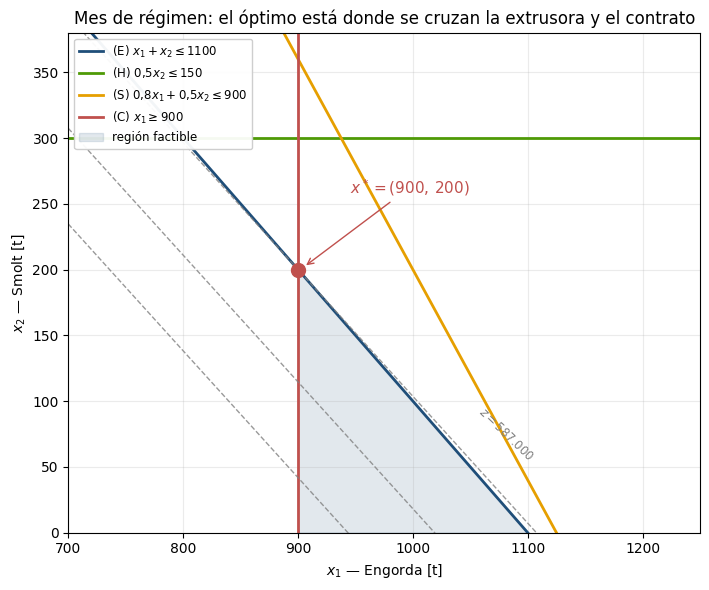

In [7]:
# Region factible y curvas de nivel
fig, ax = plt.subplots(figsize=(7.2, 6))
g1 = np.linspace(0, 1300, 400)

ax.plot(g1, 1100 - g1, lw=2, color="#1f4e79", label=r"(E) $x_1+x_2\leq 1100$")
ax.axhline(300, lw=2, color="#4e9a06", label=r"(H) $0{,}5x_2\leq 150$")
ax.plot(g1, (900 - 0.8*g1)/0.5, lw=2, color="#e69f00", label=r"(S) $0{,}8x_1+0{,}5x_2\leq 900$")
ax.axvline(900, lw=2, color="#c0504d", label=r"(C) $x_1\geq 900$")

# region factible: x1>=900, x1+x2<=1100, resto holgado
poly = np.array([[900, 0], [1100, 0], [900, 200]])
ax.fill(poly[:,0], poly[:,1], color="#1f4e79", alpha=.13, label="región factible")

for z in [500000, 540000, 587000]:
    ax.plot(g1, (z - 530*g1)/550, ls="--", lw=1, color="gray", alpha=.8)
ax.annotate(r"$z=587.000$", xy=(1055, 55), fontsize=8.5, color="gray", rotation=-44)

ax.plot([900], [200], "o", color="#c0504d", ms=10, zorder=6)
ax.annotate(r"$x^*=(900,\,200)$", xy=(905, 202), xytext=(945, 258), fontsize=11,
            arrowprops=dict(arrowstyle="->", color="#c0504d"), color="#c0504d")

ax.set_xlim(700, 1250); ax.set_ylim(0, 380)
ax.set_xlabel(r"$x_1$ — Engorda [t]"); ax.set_ylabel(r"$x_2$ — Smolt [t]")
ax.set_title("Mes de régimen: el óptimo está donde se cruzan la extrusora y el contrato")
ax.grid(alpha=.25); ax.legend(fontsize=8.5, loc="upper left", framealpha=.95)
plt.tight_layout(); plt.show()

El gráfico deja ver algo importante: la región factible es el **triángulo** que dejan el contrato y la extrusora. Las restricciones de **harina de pescado** y **soya** pasan por fuera —no tocan el triángulo— y por eso su precio sombra tendrá que ser cero.

## 2.8 El dual

El primal es de **máximo**, con dos variables $\ge0$ y cuatro restricciones: **tres de tipo $\le$** (E, H, S) y **una de tipo $\ge$** (C). Aplicando la tabla de la Sección 0.2:

- $y_E,\,y_H,\,y_S\ \ge 0$ (restricciones $\le$),
- $y_C\ \le 0$ (restricción $\ge$),
- una restricción dual $\ge$ por cada variable primal.

$$\min\; w=1.100\,y_E+150\,y_H+900\,y_S+900\,y_C$$
$$\text{s.a.}\quad
\begin{cases}
y_E+0{,}8\,y_S+y_C\ \ge\ 530 & \text{(columna de }x_1\text{: Engorda)}\\
y_E+0{,}5\,y_H+0{,}5\,y_S\ \ \ \ \ \ \ \ \;\ge\ 550 & \text{(columna de }x_2\text{: Smolt)}\\
y_E,y_H,y_S\ge0,\qquad y_C\le0
\end{cases}$$

**Lectura económica del dual.** $y_i$ es el **valor imputado** a una unidad del recurso $i$. El dual busca el sistema de precios internos **más barato** que haga que ningún producto quede subvalorado: la restricción de la columna de $x_1$ dice *"los recursos que consume una tonelada de Engorda deben valer al menos su margen de $530$"*. El contrato aparece con signo negativo porque **no es un recurso: es una obligación**.

> **El truco para no equivocarse con el signo.** Si prefiere trabajar solo con multiplicadores $\ge0$, reescriba (C) como $-x_1\le-900$ y llámele $\mu_C\ge0$. Entonces $y_C=-\mu_C$. Es el mismo número; lo único que cambia es sobre qué forma de la restricción se está reportando. Gurobi reporta $y_C=\partial z^*/\partial b_C$ sobre la restricción **tal como se escribió**.

## 2.11 Precios sombra a mano

Ambas variables son positivas ($x_1^*=900>0$, $x_2^*=200>0$), así que por holgura complementaria **las dos restricciones duales están activas** (con igualdad). Y las restricciones primales H y S tienen holgura, así que $y_H=y_S=0$. Quedan dos ecuaciones con dos incógnitas:

$$\begin{cases} y_E+0{,}8(0)+y_C=530 & \text{(Engorda)}\\ y_E+0{,}5(0)+0{,}5(0)=550 & \text{(Smolt)}\end{cases}
\;\Longrightarrow\;\boxed{y_E=550,\qquad y_C=530-550=-20}$$

$$\boxed{y^*=(y_E,\,y_H,\,y_S,\,y_C)=(550,\;0,\;0,\;-20)}$$

## 2.9 Dualidad fuerte

$$w^*=1.100(550)+150(0)+900(0)+900(-20)=605.000-18.000=587.000=z^*\quad\checkmark$$

## 2.10 Holguras complementarias

**Por restricción**, $y_i^*\,(\text{holgura}_i)=0$:

| Restricción | Holgura | $y_i^*$ | Producto | ✔ |
|:--|--:|--:|--:|:--:|
| (E) extrusora | $0$ | $550$ | $0$ | ✔ |
| (H) harina de pescado | $50$ | $0$ | $0$ | ✔ |
| (S) soya | $80$ | $0$ | $0$ | ✔ |
| (C) contrato | $0$ | $-20$ | $0$ | ✔ |

**Por variable**, $x_j^*\,(\text{holgura dual}_j)=0$: $x_1^*=900>0$ y la restricción dual de Engorda vale $550+0-20=530=c_1$ (activa) ✔; $x_2^*=200>0$ y la de Smolt vale $550+0+0=550=c_2$ (activa) ✔.

**Todas se cumplen.**

## Interpretación de negocio (pregunta 11)

| Precio sombra | Valor | Lectura |
|:--|--:|:--|
| $y_E=550$ | \$550 mil/t | **una tonelada más de capacidad de extrusora vale \$550 mil.** Es el cuello de botella, y su valor es exactamente el margen del **Smolt**: con el contrato pegado en $900$ t, cualquier capacidad adicional se usa para hacer más Smolt |
| $y_H=0$ | — | **sobran $50$ t de harina de pescado.** Comprar más cuota de pesca no sirve de nada: lo que falta es máquina, no materia prima |
| $y_S=0$ | — | **sobran $80$ t de soya.** Ídem |
| $y_C=-20$ | −\$20 mil/t | **cada tonelada adicional comprometida por contrato cuesta \$20 mil de margen.** El contrato **obliga** a hacer Engorda donde la planta preferiría hacer Smolt, y el sacrificio es exactamente la diferencia de márgenes, $550-530=20$ |

Ese $-20$ es la cifra más útil de todo el ejercicio: **es el precio mínimo al que AquaNutrí debería negociar cada tonelada extra de contrato**. Si la salmonera quiere $100$ t más de Engorda comprometidas, eso vale $\$2.000$ mil de margen sacrificado, y ese es el piso de la negociación.

> **El signo no es un tecnicismo.** Un precio sombra positivo dice *"cuánto pagaría por más"*; uno negativo dice *"cuánto me cuesta que me obliguen a más"*. Confundirlos invierte la recomendación de negocio.

In [8]:
# Dual resuelto como problema APARTE, para comprobar dualidad fuerte de forma independiente
mD = gp.Model("regimen_dual"); mD.Params.OutputFlag = 0
yE = mD.addVar(name="yE")                                  # <=  ->  y >= 0
yH = mD.addVar(name="yH")
yS = mD.addVar(name="yS")
yC = mD.addVar(ub=0.0, lb=-GRB.INFINITY, name="yC")         # >=  ->  y <= 0

mD.setObjective(1100*yE + 150*yH + 900*yS + 900*yC, GRB.MINIMIZE)
mD.addConstr(yE + 0.8*yS + yC       >= 530, "col_x1_Engorda")
mD.addConstr(yE + 0.5*yH + 0.5*yS   >= 550, "col_x2_Smolt")
mD.optimize()

print(f"DUAL   y* = (yE, yH, yS, yC) = ({yE.X:,.1f}, {yH.X:,.1f}, {yS.X:,.1f}, {yC.X:,.1f})")
print(f"       w* = {mD.ObjVal:,.0f} $ mil")
print(f"PRIMAL z* = {mP.ObjVal:,.0f} $ mil")
print(f"\nDualidad fuerte:  |z* - w*| = {abs(mP.ObjVal - mD.ObjVal):.2e}   -> se cumple")
print("Los precios sombra del primal coinciden con la solucion del dual:",
      np.allclose([cE.Pi, cH.Pi, cS.Pi, cC.Pi], [yE.X, yH.X, yS.X, yC.X]))

print("\nHolguras complementarias")
print("  por restriccion  max |Pi * Slack| =",
      f"{max(abs(c.Pi*c.Slack) for c in (cE,cH,cS,cC)):.2e}")
hol_dual = {"x1": (cE.Pi + 0.8*cS.Pi + cC.Pi) - 530,
            "x2": (cE.Pi + 0.5*cH.Pi + 0.5*cS.Pi) - 550}
for j, (nom, val) in enumerate(zip(["x1","x2"], [x1.X, x2.X])):
    print(f"  por variable     {nom} = {val:6,.0f}  holgura dual = {hol_dual[nom]:+.2e}"
          f"   producto = {val*hol_dual[nom]:.2e}")

DUAL   y* = (yE, yH, yS, yC) = (550.0, 0.0, 0.0, -20.0)
       w* = 587,000 $ mil
PRIMAL z* = 587,000 $ mil

Dualidad fuerte:  |z* - w*| = 0.00e+00   -> se cumple
Los precios sombra del primal coinciden con la solucion del dual: True

Holguras complementarias
  por restriccion  max |Pi * Slack| = 0.00e+00
  por variable     x1 =    900  holgura dual = +0.00e+00   producto = 0.00e+00
  por variable     x2 =    200  holgura dual = +0.00e+00   producto = 0.00e+00


## 2.12 ¿Conviene subir el contrato a 950 t? (pregunta 12)

**Sí se puede responder con el precio sombra**, y esta vez sí, porque el salto es **chico y está dentro del rango de validez**. La predicción es

$$\Delta z \;\approx\; y_C\times\Delta b_C \;=\;(-20)\times 50\;=\;-1.000\ \text{\$ mil},$$

es decir la planta **pierde \$1.000 mil** de margen, contra un pago de \$800 mil. **No conviene**: falta \$200 mil. El precio de indiferencia es $\$20$ mil por tonelada, o sea $\$1.000$ mil por las $50$ t.

Lo comprobamos, y de paso miramos el **rango de validez** para saber hasta dónde vale ese $-20$.

In [9]:
print(f"Rango de validez del RHS del contrato: [{cC.SARHSLow:,.0f}, {cC.SARHSUp:,.0f}] t"
      f"   (RHS actual = {cC.RHS:,.0f})")
print(f"Rango de validez del RHS de la extrusora: [{cE.SARHSLow:,.0f}, {cE.SARHSUp:,.0f}] t\n")

def regimen(bC=900., bE=1100.):
    """Optimo del LP de regimen para lados derechos (bC, bE). np.nan si es infactible."""
    mm = gp.Model(); mm.Params.OutputFlag = 0
    a = mm.addVar(); b = mm.addVar()
    mm.setObjective(530*a + 550*b, GRB.MAXIMIZE)
    mm.addConstr(a + b <= bE); mm.addConstr(0.5*b <= 150)
    mm.addConstr(0.8*a + 0.5*b <= 900); mm.addConstr(a >= bC)
    mm.optimize()
    return mm.ObjVal if mm.Status == GRB.OPTIMAL else np.nan

base = mP.ObjVal
filas = []
for bC in [900, 920, 950, 1000, 1100, 1150]:
    real = regimen(bC=bC) - base
    filas.append(dict(contrato=bC,
                      delta_real="INFACTIBLE" if np.isnan(real) else round(real, 1),
                      prediccion_Pi=round(cC.Pi*(bC-900), 1),
                      en_rango="si" if bC <= cC.SARHSUp + 1e-6 else "NO"))
display(pd.DataFrame(filas))

oferta, delta_b = 800.0, 50.0
print(f"\nOferta: +{delta_b:.0f} t de contrato por un pago unico de {oferta:,.0f} $ mil")
print(f"  costo real del compromiso = {-(regimen(bC=950.) - base):,.0f} $ mil")
print(f"  resultado neto            = {oferta + (regimen(bC=950.) - base):,.0f} $ mil"
      f"   ->  {'CONVIENE' if oferta + (regimen(bC=950.)-base) > 0 else 'NO CONVIENE'}")
print(f"  precio de indiferencia    = {-cC.Pi*delta_b:,.0f} $ mil "
      f"({-cC.Pi:,.0f} $ mil por tonelada)")

Rango de validez del RHS del contrato: [800, 1,100] t   (RHS actual = 900)
Rango de validez del RHS de la extrusora: [900, 1,200] t



,contrato,delta_real,prediccion_Pi,en_rango
0,900,0.0,-0.0,si
1,920,-400.0,-400.0,si
2,950,-1000.0,-1000.0,si
3,1000,-2000.0,-2000.0,si
4,1100,-4000.0,-4000.0,si
5,1150,INFACTIBLE,-5000.0,NO



Oferta: +50 t de contrato por un pago unico de 800 $ mil
  costo real del compromiso = 1,000 $ mil
  resultado neto            = -200 $ mil   ->  NO CONVIENE
  precio de indiferencia    = 1,000 $ mil (20 $ mil por tonelada)


Dentro del rango $[800,\,1.100]$ la predicción del precio sombra es **exacta**: el contrato cuesta $\$20$ mil por tonelada, ni más ni menos. Y el borde superior del rango tiene una lectura brutal: con $b_C=1.100$ el contrato se come **toda** la extrusora y el Smolt desaparece del plan; **más allá de $1.100$ t el problema se vuelve infactible**, porque no hay capacidad para cumplirlo. El precio sombra no avisa nada de eso —solo dice "$-20$ por tonelada"—, y por eso **siempre hay que mirar el rango de validez antes de citarlo**. Es la misma lección de la Ayudantía 7: el precio sombra responde *"un poco más"*, no *"el doble"*.

---

# Ejercicio 3 — **KKT**: la teoría detrás de los precios sombra

Ahora vamos a mirar el mismo problema desde KKT. Primero verificamos que, para el LP del Ejercicio 2, **KKT no dice nada nuevo**: es la dualidad. Después rompemos la linealidad y vemos que **KKT sobrevive y la dualidad, tal como la conocíamos, no**.

### Contexto de la parte no lineal

El mercado del Smolt es **chico**: AquaNutrí es uno de tres proveedores en la región y, para colocar más toneladas, tiene que **bajar el precio**. El área comercial estima que el precio de venta cae linealmente con el volumen,

$$pr_{\text{SM}}(x_2)=1.600-0{,}04\,x_2\quad[\text{\$ mil/t}],$$

mientras el costo de la receta se mantiene en $\$1.050$ mil/t. El margen del Engorda no cambia (es un contrato a precio fijo). La función objetivo pasa a ser

$$f(x_1,x_2)=530\,x_1+\underbrace{\big(1.600-0{,}04x_2-1.050\big)}_{\text{margen unitario del Smolt}}x_2=530\,x_1+550\,x_2-0{,}04\,x_2^2,$$

**con las mismas cuatro restricciones del Ejercicio 2.**

### Se pide

**Parte (a) — KKT sobre el LP.**

13. Escriba el **Lagrangiano** del LP del Ejercicio 2 (todas las restricciones en forma $g_i(x)\le0$) y las **cuatro condiciones KKT**.
14. Verifique que $x^*=(900,200)$ con $\mu^*=(\mu_E,\mu_H,\mu_S,\mu_C)=(550,0,0,20)$ las satisface, y explique la relación entre $\mu^*$ y los precios sombra $y^*$ del Ejercicio 2. ¿Por qué $\mu_C=+20$ y $y_C=-20$?

**Parte (b) — KKT sobre el problema no lineal.**

15. Justifique que el problema es **cóncavo** y que, por lo tanto, KKT es **suficiente** y el punto que encuentre será óptimo **global**.
16. Escriba las condiciones KKT y resuélvalas **enumerando los casos** de restricciones activas/inactivas, como en la Clase 29. Reporte $x^*$, $f^*$ y $\mu^*$.
17. Verifique numéricamente que $\mu_i^*=\partial f^*/\partial b_i$ para la extrusora y para el contrato.
18. Compare con el LP del Ejercicio 2: ¿cambió el óptimo? ¿cambiaron los precios sombra? ¿qué le diría a la gerencia sobre el contrato ahora?

---

# Solución — Ejercicio 3

## Parte (a) — KKT sobre el LP

### 3.13 Lagrangiano y condiciones (pregunta 13)

Primero llevamos **todas** las restricciones a la forma $g_i(x)\le0$. Ojo con el contrato, que es $\ge$ y hay que darlo vuelta:

$$g_E=x_1+x_2-1.100\le0,\qquad g_H=0{,}5x_2-150\le0,$$
$$g_S=0{,}8x_1+0{,}5x_2-900\le0,\qquad g_C=\underbrace{900-x_1}_{\text{¡invertida!}}\le0,$$

más las de no negatividad $-x_1\le0$, $-x_2\le0$ con multiplicadores $\sigma_1,\sigma_2\ge0$. El Lagrangiano:

$$\mathcal L=530x_1+550x_2-\mu_E g_E-\mu_H g_H-\mu_S g_S-\mu_C g_C+\sigma_1x_1+\sigma_2x_2$$

**Estacionariedad** ($\nabla f=\sum\mu_i\nabla g_i$, con $\sigma_j=0$ porque $x_j^*>0$):

$$\frac{\partial\mathcal L}{\partial x_1}=0:\quad 530=\mu_E\cdot1+\mu_H\cdot0+\mu_S\cdot0{,}8+\mu_C\cdot(-1)$$
$$\frac{\partial\mathcal L}{\partial x_2}=0:\quad 550=\mu_E\cdot1+\mu_H\cdot0{,}5+\mu_S\cdot0{,}5+\mu_C\cdot0$$

**Factibilidad primal:** $g_i(x^*)\le0$ para las cuatro. **Factibilidad dual:** $\mu_i\ge0$.
**Holgura complementaria:** $\mu_E g_E=\mu_H g_H=\mu_S g_S=\mu_C g_C=0$.

### 3.14 Verificación y relación con los precios sombra (pregunta 14)

De la holgura complementaria: H y S tienen holgura ($g_H=-50$, $g_S=-80$), luego $\mu_H=\mu_S=0$. Sustituyendo:

$$550=\mu_E\quad\Longrightarrow\quad \mu_E=550,\qquad 530=550-\mu_C\quad\Longrightarrow\quad \mu_C=20.$$

Las cuatro condiciones se cumplen: $\mu=(550,0,0,20)\ge0$ ✔, $x^*=(900,200)$ es factible ✔, cada producto $\mu_ig_i=0$ ✔, y la estacionariedad se verifica por construcción ✔. Como el problema es lineal (por lo tanto cóncavo, y con cualificación de restricciones automática), **KKT es necesaria y suficiente: $x^*$ es óptimo global.**

**Sobre los signos.** Los multiplicadores KKT son **siempre $\ge0$**, porque KKT exige escribir todo como $g_i\le0$. El precio sombra que reporta el solver, en cambio, es $\partial z^*/\partial b_i$ sobre la restricción **tal como fue escrita**:

| Restricción | Como se escribió | Como la ve KKT | $\mu_i$ | $y_i=\partial z^*/\partial b_i$ |
|:--|:--|:--|--:|--:|
| (E) extrusora | $x_1+x_2\le1.100$ | $g_E\le0$, mismo sentido | $550$ | $+550$ |
| (H) harina | $0{,}5x_2\le150$ | mismo sentido | $0$ | $0$ |
| (S) soya | $0{,}8x_1+0{,}5x_2\le900$ | mismo sentido | $0$ | $0$ |
| (C) contrato | $x_1\ge900$ | $900-x_1\le0$, **invertida** | $20$ | $-20$ |

$$\boxed{\;y_i=+\mu_i\ \text{si la restricción era }\le,\qquad y_i=-\mu_i\ \text{si era }\ge\;}$$

El $\mu_C=20$ dice *"el multiplicador de la obligación vale 20"*; el $y_C=-20$ dice *"subir la obligación en una tonelada me cuesta 20"*. **Es el mismo hecho económico enunciado desde los dos lados.** Y confirma la identificación de la Sección 0.4: $\mu^*$ y $y^*$ son el mismo objeto, salvo el signo que impone la convención.

In [10]:
print("VERIFICACION DE LAS CUATRO CONDICIONES KKT SOBRE EL LP\n")
xs  = np.array([900., 200.])
mu  = np.array([550., 0., 0., 20.])                 # (E, H, S, C)   siempre >= 0
nombres = ["E extrusora", "H harina pescado", "S soya", "C contrato"]

grad_f = np.array([530., 550.])                     # objetivo lineal
g      = np.array([xs[0]+xs[1]-1100, 0.5*xs[1]-150, 0.8*xs[0]+0.5*xs[1]-900, 900-xs[0]])
grad_g = np.array([[1., 1.], [0., 0.5], [0.8, 0.5], [-1., 0.]])   # una fila por restriccion

print("1) ESTACIONARIEDAD   grad f = sum_i mu_i grad g_i")
print(f"     grad f          = {grad_f}")
print(f"     sum mu_i grad g = {mu @ grad_g}")
print(f"     residuo         = {np.abs(grad_f - mu @ grad_g).max():.2e}\n")

print("2) FACTIBILIDAD PRIMAL   g_i(x*) <= 0")
for n, gi in zip(nombres, g):
    print(f"     {n:<20} g = {gi:>8,.1f}   {'activa' if abs(gi)<1e-9 else 'holgada'}")

print("\n3) FACTIBILIDAD DUAL   mu_i >= 0")
print(f"     mu = {mu}   ->  {'OK' if (mu >= -1e-9).all() else 'FALLA'}")

print("\n4) HOLGURA COMPLEMENTARIA   mu_i * g_i(x*) = 0")
for n, mi, gi in zip(nombres, mu, g):
    print(f"     {n:<20} mu={mi:>7,.1f}  g={gi:>8,.1f}  producto={mi*gi:>8.2e}")

print(f"\nSe cumplen las cuatro  ->  x* = {xs} es optimo GLOBAL (problema lineal = concavo)")
print(f"\nContraste con los precios sombra de Gurobi (Ejercicio 2):")
print(f"{'restriccion':<20}{'tipo':>6}{'mu (KKT)':>11}{'y (Gurobi)':>13}")
for n, tipo, mi, c in zip(nombres, ["<=","<=","<=",">="], mu, [cE, cH, cS, cC]):
    print(f"{n:<20}{tipo:>6}{mi:>11,.1f}{c.Pi:>13,.1f}")

VERIFICACION DE LAS CUATRO CONDICIONES KKT SOBRE EL LP

1) ESTACIONARIEDAD   grad f = sum_i mu_i grad g_i
     grad f          = [530. 550.]
     sum mu_i grad g = [530. 550.]
     residuo         = 0.00e+00

2) FACTIBILIDAD PRIMAL   g_i(x*) <= 0
     E extrusora          g =      0.0   activa
     H harina pescado     g =    -50.0   holgada
     S soya               g =    -80.0   holgada
     C contrato           g =      0.0   activa

3) FACTIBILIDAD DUAL   mu_i >= 0
     mu = [550.   0.   0.  20.]   ->  OK

4) HOLGURA COMPLEMENTARIA   mu_i * g_i(x*) = 0
     E extrusora          mu=  550.0  g=     0.0  producto=0.00e+00
     H harina pescado     mu=    0.0  g=   -50.0  producto=-0.00e+00
     S soya               mu=    0.0  g=   -80.0  producto=-0.00e+00
     C contrato           mu=   20.0  g=     0.0  producto=0.00e+00

Se cumplen las cuatro  ->  x* = [900. 200.] es optimo GLOBAL (problema lineal = concavo)

Contraste con los precios sombra de Gurobi (Ejercicio 2):
restriccion  

## Parte (b) — KKT sobre el problema no lineal

### 3.15 Concavidad y suficiencia (pregunta 15)

$$f(x_1,x_2)=530x_1+550x_2-0{,}04x_2^2,\qquad
\nabla f=\begin{bmatrix}530\\ 550-0{,}08x_2\end{bmatrix},\qquad
\nabla^2 f=\begin{bmatrix}0&0\\0&-0{,}08\end{bmatrix}.$$

La Hessiana es **constante** y **semidefinida negativa** (valores propios $0$ y $-0{,}08$, ambos $\le0$), luego $f$ es **cóncava**. Dicho sin matrices: $530x_1$ y $550x_2$ son lineales (cóncavas), $-0{,}04x_2^2$ es cóncava, y la suma de cóncavas es cóncava.

Las cuatro restricciones son **lineales**, así que el conjunto factible es un **poliedro**: convexo. Estamos maximizando una función cóncava sobre un conjunto convexo, es decir en un problema **cóncavo**:

- las restricciones lineales garantizan la **cualificación** ⟹ KKT es **necesaria**;
- la concavidad garantiza que KKT es **suficiente**.

$$\boxed{\text{Cualquier punto que satisfaga KKT es óptimo }\textbf{global}.}$$

Es exactamente el argumento que el profesor usó en la Clase 29 (Ejercicio 30) antes de escribir el Lagrangiano: **primero se justifica la convexidad, después se resuelve.**

### 3.16 Condiciones KKT y enumeración de casos (pregunta 16)

Con los mismos $g_E,g_H,g_S,g_C$ de antes, la **estacionariedad** es ahora

$$\begin{cases}
\dfrac{\partial f}{\partial x_1}=530&=\ \mu_E+0{,}8\,\mu_S-\mu_C\\[8pt]
\dfrac{\partial f}{\partial x_2}=550-0{,}08\,x_2&=\ \mu_E+0{,}5\,\mu_H+0{,}5\,\mu_S
\end{cases}$$

La **única** diferencia con el LP es que ahora la segunda ecuación **contiene a $x_2$**: los multiplicadores dejan de ser constantes y dependen del punto. Ahí se rompe la dualidad lineal, y ahí es donde KKT sigue sirviendo.

**Un descarte que ahorra la mitad del trabajo.** La primera ecuación exige $\mu_E+0{,}8\mu_S-\mu_C=530>0$, así que **no pueden ser cero las tres a la vez**: al menos una de E, S, C debe estar activa. Eso elimina de entrada todos los casos en que las activas se reducen a $\{\}$ o $\{H\}$.

**Casos principales:**

| Caso | Activas | Se obtiene | Veredicto |
|:--|:--|:--|:--|
| 1 | $\{E\}$ | $\mu_E=530$; $550-0{,}08x_2=530\Rightarrow x_2=250$, $x_1=850$ | ✗ **viola el contrato** ($850<900$) |
| 2 | $\{E,H\}$ | $x_2=300$, $x_1=800$, $\mu_E=530$, $\mu_H=-8$ | ✗ $\mu_H<0$ (y viola el contrato) |
| 3 | $\{E,S\}$ | $x_2=-66{,}7$ | ✗ $x_2<0$ |
| 4 | $\{C\}$ | $\mu_C=-530$ | ✗ $\mu_C<0$ |
| 5 | $\{H,S\}$ | $x=(937{,}5,\;300)$ | ✗ viola la extrusora |
| **6** | $\boldsymbol{\{E,C\}}$ | $x_1=900$, $x_2=200$; $\mu_E=550-0{,}08(200)=534$, $\mu_C=534-530=4$ | ✔ **cumple KKT** |
| 7 | $\{E,H,S\}$, $\{E,H,C\}$, … | tres restricciones activas y dos variables | ✗ sistemas incompatibles |

**El caso 6 en detalle.** Activas E y C: $x_1=900$ (contrato) y $x_1+x_2=1.100$ (extrusora), luego $x_2=200$. Con $\mu_H=\mu_S=0$:

$$550-0{,}08(200)=534=\mu_E\qquad\Longrightarrow\qquad 530=534-\mu_C\;\Rightarrow\;\mu_C=4.$$

Todo cierra: $\mu=(534,\,0,\,0,\,4)\ge0$ ✔, $x^*$ factible ✔, holgura complementaria ✔.

$$\boxed{x^*=(900,\;200),\qquad f^*=585.400\ \text{\$ mil},\qquad \mu^*=(534,\,0,\,0,\,4)}$$

$$f^*=530(900)+550(200)-0{,}04(200)^2=477.000+110.000-1.600=585.400$$

Como el problema es cóncavo, **este punto es el óptimo global** y no hace falta revisar nada más.

In [11]:
# --- Enumeracion sistematica de los 2^4 casos (verifica la tabla hecha a mano) ---
grad_g = np.array([[1., 1.], [0., 0.5], [0.8, 0.5], [-1., 0.]])
rhs_g  = np.array([1100., 150., 900., 900.])          # E, H, S: <= ; C: x1 >= 900
nom    = ["E", "H", "S", "C"]

def g_vec(z):
    return np.array([z[0]+z[1]-1100, 0.5*z[1]-150, 0.8*z[0]+0.5*z[1]-900, 900-z[0]])

def f_nl(z):
    return 530*z[0] + 550*z[1] - 0.04*z[1]**2

filas = []
for act in itertools.chain.from_iterable(itertools.combinations(range(4), r) for r in range(5)):
    n = 2 + len(act)
    M = np.zeros((n, n)); b = np.zeros(n)
    # estacionariedad en x1:  530 = sum mu_i * dg_i/dx1
    for j, i in enumerate(act): M[0, 2+j] = grad_g[i, 0]
    b[0] = 530.
    # estacionariedad en x2:  550 - 0.08 x2 = sum mu_i * dg_i/dx2
    M[1, 1] = 0.08
    for j, i in enumerate(act): M[1, 2+j] = grad_g[i, 1]
    b[1] = 550.
    # una ecuacion g_i(x) = 0 por cada restriccion activa
    for j, i in enumerate(act):
        M[2+j, 0], M[2+j, 1] = grad_g[i]
        b[2+j] = rhs_g[i] if i != 3 else -900.
        if i == 3: M[2+j, 0] = -1.
    sol, *_ = np.linalg.lstsq(M, b, rcond=None)
    etq = "{" + ",".join(nom[i] for i in act) + "}" if act else "{}"
    if np.linalg.norm(M @ sol - b) > 1e-6:
        filas.append(dict(activas=etq, x1="-", x2="-", mu="-", veredicto="sistema incompatible"))
        continue
    xx, mu_ = sol[:2], sol[2:]
    falla = []
    if (xx < -1e-7).any(): falla.append("x<0")
    if (mu_ < -1e-7).any(): falla.append("mu<0")
    for i in range(4):
        if i not in act and g_vec(xx)[i] > 1e-7: falla.append(f"viola {nom[i]}")
    filas.append(dict(activas=etq, x1=round(xx[0], 1), x2=round(xx[1], 1),
                      mu=", ".join(f"{nom[i]}={v:,.2f}" for i, v in zip(act, mu_)) or "-",
                      veredicto="KKT OK" if not falla else "X " + ", ".join(falla)))

tabla = pd.DataFrame(filas)
display(tabla)
gan = tabla[tabla.veredicto == "KKT OK"]
print("Casos que satisfacen KKT:", len(gan), " ->  optimo global (problema concavo)")
xk = np.array([float(gan.x1.iloc[0]), float(gan.x2.iloc[0])])
print(f"x* = ({xk[0]:,.0f}, {xk[1]:,.0f})   f* = {f_nl(xk):,.0f} $ mil   mu* = ({gan.mu.iloc[0]})")

,activas,x1,x2,mu,veredicto
0,{},-,-,-,sistema incompatible
1,{E},850.0,250.0,E=530.00,X viola C
2,{H},-,-,-,sistema incompatible
3,{S},-584.0,2734.4,S=662.50,"X x<0, viola E, viola H, viola C"
4,{C},900.0,6875.0,C=-530.00,"X mu<0, viola E, viola H, viola S"
5,"{E,H}",800.0,300.0,"E=530.00, H=-8.00","X mu<0, viola C"
6,"{E,S}",1166.7,-66.7,"E=597.56, S=-84.44","X x<0, mu<0"
7,"{E,C}",900.0,200.0,"E=534.00, C=4.00",KKT OK
8,"{H,S}",937.5,300.0,"H=389.50, S=662.50",X viola E
9,"{H,C}",900.0,300.0,"H=1,052.00, C=-530.00","X mu<0, viola E"


Casos que satisfacen KKT: 1  ->  optimo global (problema concavo)
x* = (900, 200)   f* = 585,400 $ mil   mu* = (E=534.00, C=4.00)


In [12]:
# Comprobacion independiente con scipy (SLSQP)
res = minimize(lambda z: -f_nl(z), x0=[900., 150.], method="SLSQP",
               bounds=[(0, None), (0, None)],
               constraints=[{"type": "ineq", "fun": lambda z: 1100 - z[0] - z[1]},
                            {"type": "ineq", "fun": lambda z: 150 - 0.5*z[1]},
                            {"type": "ineq", "fun": lambda z: 900 - 0.8*z[0] - 0.5*z[1]},
                            {"type": "ineq", "fun": lambda z: z[0] - 900}])
print(f"scipy SLSQP : x* = ({res.x[0]:,.2f}, {res.x[1]:,.2f})   f* = {-res.fun:,.2f}")
print(f"KKT a mano  : x* = (900.00, 200.00)   f* = {f_nl(np.array([900., 200.])):,.2f}")

# Y con gurobi, que admite objetivos cuadraticos
mQ = gp.Model("regimen_nolineal"); mQ.Params.OutputFlag = 0
q1 = mQ.addVar(name="x1"); q2 = mQ.addVar(name="x2")
mQ.setObjective(530*q1 + 550*q2 - 0.04*q2*q2, GRB.MAXIMIZE)
mQ.addConstr(q1 + q2 <= 1100, "E"); mQ.addConstr(0.5*q2 <= 150, "H")
mQ.addConstr(0.8*q1 + 0.5*q2 <= 900, "S"); mQ.addConstr(q1 >= 900, "C")
mQ.optimize()
print(f"gurobi (QP) : x* = ({q1.X:,.2f}, {q2.X:,.2f})   f* = {mQ.ObjVal:,.2f}")

scipy SLSQP : x* = (900.00, 200.00)   f* = 585,400.00
KKT a mano  : x* = (900.00, 200.00)   f* = 585,400.00
gurobi (QP) : x* = (900.00, 200.00)   f* = 585,400.00


### 3.17 Los multiplicadores **son** los precios sombra, también aquí (pregunta 17)

La afirmación $\mu_i^*=\partial f^*/\partial b_i$ vale igual en el caso no lineal. La comprobamos de dos maneras.

**Analíticamente.** Cerca del óptimo, la estructura de activas no cambia: $x_1=b_C$ y $x_1+x_2=b_E$, o sea $x_2=b_E-b_C$. Entonces

$$f^*(b_E,b_C)=530\,b_C+550(b_E-b_C)-0{,}04(b_E-b_C)^2,$$

$$\frac{\partial f^*}{\partial b_E}=550-0{,}08(b_E-b_C)=550-0{,}08(200)=\boxed{534}=\mu_E,$$
$$\frac{\partial f^*}{\partial b_C}=530-550+0{,}08(200)=\boxed{-4}=-\mu_C.$$

**Numéricamente**, con diferencias finitas sobre el problema re-resuelto (celda siguiente).

> **La diferencia con el LP.** En un LP el precio sombra es **constante** dentro de su rango: la predicción lineal es exacta hasta el borde. Aquí $\mu_E=550-0{,}08x_2$ **cambia con el punto**: es una **derivada**, exacta solo en el límite. Por eso, en optimización no lineal, extrapolar un multiplicador es todavía más peligroso que en un LP.

In [13]:
def f_opt(bE=1100., bC=900.):
    """Optimo del problema no lineal para lados derechos (bE, bC).
    Varios arranques: SLSQP puede quedarse pegado en un vertice si parte justo sobre el borde."""
    cons = [{"type": "ineq", "fun": lambda z: bE - z[0] - z[1]},
            {"type": "ineq", "fun": lambda z: 150 - 0.5*z[1]},
            {"type": "ineq", "fun": lambda z: 900 - 0.8*z[0] - 0.5*z[1]},
            {"type": "ineq", "fun": lambda z: z[0] - bC}]
    mejor = -np.inf
    for x0 in ([bC, max(bE-bC, 0.)], [bC, 0.], [bC, min(250., max(bE-bC, 0.))]):
        r = minimize(lambda z: -f_nl(z), x0=x0, method="SLSQP",
                     bounds=[(0, None), (0, None)],
                     options={"ftol": 1e-12, "maxiter": 800}, constraints=cons)
        if all(c["fun"](r.x) > -1e-4 for c in cons):      # tolerancia del solver
            mejor = max(mejor, -r.fun)
    return mejor

eps = 0.5
dE = (f_opt(bE=1100+eps) - f_opt(bE=1100-eps)) / (2*eps)     # diferencia central
dC = (f_opt(bC= 900+eps) - f_opt(bC= 900-eps)) / (2*eps)

print(f"{'recurso':<24}{'mu (KKT)':>11}{'df*/db (numerico)':>21}{'y = df*/db':>13}")
print(f"{'E  extrusora  (<=)':<24}{534:>11.2f}{dE:>21.4f}{534:>13.2f}")
print(f"{'C  contrato   (>=)':<24}{4:>11.2f}{dC:>21.4f}{-4:>13.2f}")

print(f"\nY el multiplicador depende del punto:  mu_E = 550 - 0.08*x2")
for b in [1000., 1050., 1100., 1150.]:
    x2b = min(b - 900., 250.)
    print(f"   b_E = {b:>7,.0f}  ->  x2* = {x2b:>6,.1f}   mu_E = {550-0.08*x2b:>7,.2f}")

recurso                    mu (KKT)    df*/db (numerico)   y = df*/db
E  extrusora  (<=)           534.00             534.0013       534.00
C  contrato   (>=)             4.00              -4.0013        -4.00

Y el multiplicador depende del punto:  mu_E = 550 - 0.08*x2
   b_E =   1,000  ->  x2* =  100.0   mu_E =  542.00
   b_E =   1,050  ->  x2* =  150.0   mu_E =  538.00
   b_E =   1,100  ->  x2* =  200.0   mu_E =  534.00
   b_E =   1,150  ->  x2* =  250.0   mu_E =  530.00


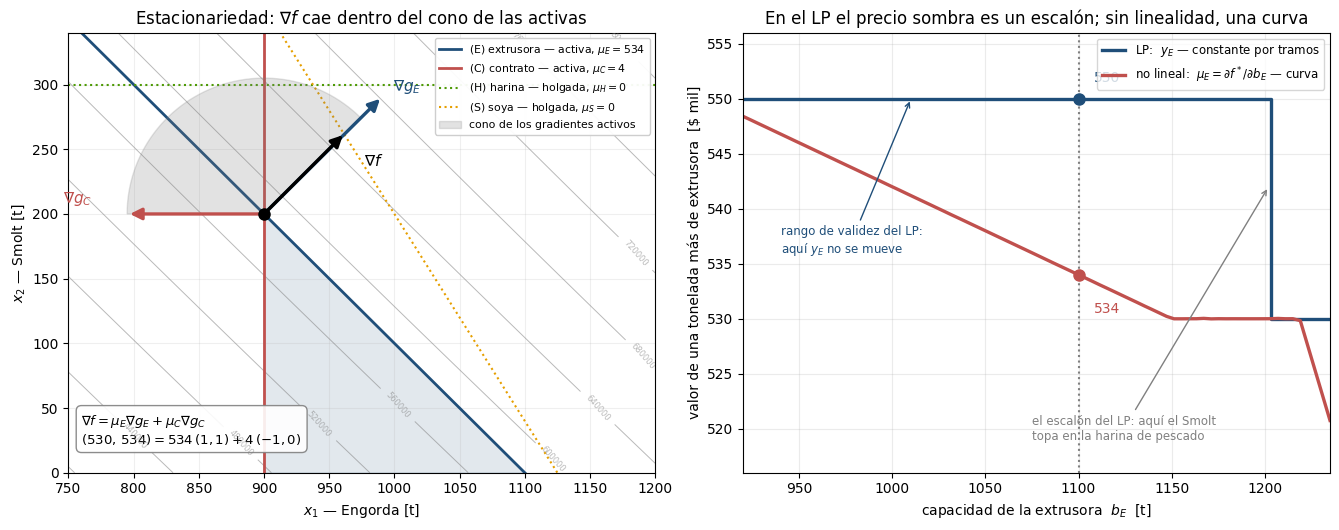

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(13.5, 5.4))

# ================= (izq) el cono de los gradientes activos =================
gx = np.linspace(750, 1200, 300); gy = np.linspace(0, 340, 300)
GX, GY = np.meshgrid(gx, gy)
cs = ax[0].contour(GX, GY, 530*GX + 550*GY - 0.04*GY**2, levels=12,
                   colors="gray", linewidths=.7, alpha=.55)
ax[0].clabel(cs, inline=True, fontsize=6, fmt="%.0f")

poly = np.array([[900, 0], [1100, 0], [900, 200]])
ax[0].fill(poly[:,0], poly[:,1], color="#1f4e79", alpha=.13)
ax[0].plot(gx, 1100-gx, lw=2, color="#1f4e79", label=r"(E) extrusora — activa, $\mu_E=534$")
ax[0].axvline(900, lw=2, color="#c0504d", label=r"(C) contrato — activa, $\mu_C=4$")
ax[0].axhline(300, lw=1.5, ls=":", color="#4e9a06", label=r"(H) harina — holgada, $\mu_H=0$")
ax[0].plot(gx, (900-0.8*gx)/0.5, lw=1.5, ls=":", color="#e69f00",
           label=r"(S) soya — holgada, $\mu_S=0$")

# cono generado por los gradientes de las restricciones ACTIVAS
xo = np.array([900., 200.]); Rad = 105.
dE = np.array([1., 1.])/np.sqrt(2)          # grad g_E
dC = np.array([-1., 0.])                    # grad g_C
ang = np.linspace(np.arctan2(*dE[::-1]), np.arctan2(*dC[::-1]), 60)
cono = np.vstack([xo, xo + Rad*np.c_[np.cos(ang), np.sin(ang)]])
ax[0].fill(cono[:,0], cono[:,1], color="#7f7f7f", alpha=.22, zorder=4,
           label="cono de los gradientes activos")

df = np.array([530., 534.]); df = df/np.linalg.norm(df)     # grad f normalizado
for d, col, lab, rad, z, off in [(dE, "#1f4e79", r"$\nabla g_E$", 128., 7, (8, 4)),
                                 (dC, "#c0504d", r"$\nabla g_C$", 105., 7, (-46, 8)),
                                 (df, "black",   r"$\nabla f$",   88.,  8, (14, -24))]:
    ax[0].annotate("", xy=xo + rad*d, xytext=xo, zorder=z,
                   arrowprops=dict(arrowstyle="-|>", lw=2.4, color=col, mutation_scale=17))
    ax[0].annotate(lab, xy=xo + rad*d, xytext=off, textcoords="offset points",
                   color=col, fontsize=11, zorder=9)
ax[0].plot(*xo, "o", color="black", ms=8, zorder=9)

ax[0].text(760, 22, r"$\nabla f=\mu_E\nabla g_E+\mu_C\nabla g_C$" "\n"
                    r"$(530,\,534)=534\,(1,1)+4\,(-1,0)$",
           fontsize=9.5, bbox=dict(boxstyle="round,pad=.4", fc="white", ec="gray", alpha=.9))
ax[0].set_xlim(750, 1200); ax[0].set_ylim(0, 340)
ax[0].set_xlabel(r"$x_1$ — Engorda [t]"); ax[0].set_ylabel(r"$x_2$ — Smolt [t]")
ax[0].set_title(r"Estacionariedad: $\nabla f$ cae dentro del cono de las activas")
ax[0].legend(fontsize=7.8, loc="upper right", framealpha=.95); ax[0].grid(alpha=.2)

# ============ (der) el multiplicador mismo, como funcion del RHS ============
def pi_lp(bE):
    """Precio sombra de la extrusora en el LP, para una capacidad bE."""
    mm = gp.Model(); mm.Params.OutputFlag = 0
    a_ = mm.addVar(); b_ = mm.addVar()
    mm.setObjective(530*a_ + 550*b_, GRB.MAXIMIZE)
    cE_ = mm.addConstr(a_ + b_ <= bE); mm.addConstr(0.5*b_ <= 150)
    mm.addConstr(0.8*a_ + 0.5*b_ <= 900); mm.addConstr(a_ >= 900)
    mm.optimize()
    return cE_.Pi if mm.Status == GRB.OPTIMAL else np.nan

def pi_nl(bE, e=0.25):
    """Multiplicador de la extrusora en el problema no lineal, por su DEFINICION:
    mu_E = df*/db_E, con diferencias finitas centradas."""
    return (f_opt(bE=bE+e) - f_opt(bE=bE-e)) / (2*e)

grid = np.linspace(920, 1235, 80)
v_lp = np.array([pi_lp(float(b)) for b in grid])
v_nl = np.array([pi_nl(float(b)) for b in grid])

ax[1].step(grid, v_lp, where="post", lw=2.4, color="#1f4e79",
           label=r"LP:  $y_E$ — constante por tramos")
ax[1].plot(grid, v_nl, lw=2.4, color="#c0504d",
           label=r"no lineal:  $\mu_E=\partial f^*/\partial b_E$ — curva")
ax[1].axvline(1100, ls=":", color="gray")
ax[1].plot([1100], [550], "o", color="#1f4e79", ms=8, zorder=5)
ax[1].plot([1100], [534], "o", color="#c0504d", ms=8, zorder=5)
ax[1].annotate("550", xy=(1100, 550), xytext=(1108, 551.5), color="#1f4e79", fontsize=10)
ax[1].annotate("534", xy=(1100, 534), xytext=(1108, 530.5), color="#c0504d", fontsize=10)
ax[1].annotate("rango de validez del LP:\naquí $y_E$ no se mueve",
               xy=(1010, 550), xytext=(940, 536), fontsize=8.5, color="#1f4e79",
               arrowprops=dict(arrowstyle="->", color="#1f4e79"))
ax[1].annotate("el escalón del LP: aquí el Smolt\ntopa en la harina de pescado",
               xy=(1202, 542), xytext=(1075, 519), fontsize=8.5, color="gray",
               arrowprops=dict(arrowstyle="->", color="gray"))
ax[1].set_xlabel(r"capacidad de la extrusora  $b_E$  [t]")
ax[1].set_ylabel(r"valor de una tonelada más de extrusora  [\$ mil]")
ax[1].set_title("En el LP el precio sombra es un escalón; sin linealidad, una curva")
ax[1].set_xlim(920, 1235); ax[1].set_ylim(516, 556)
ax[1].legend(fontsize=8.5, loc="upper right"); ax[1].grid(alpha=.25)

plt.tight_layout(); plt.show()

En el panel izquierdo se ve la **estacionariedad** con los ojos. Las dos restricciones **activas** generan un **cono** (la zona gris) con sus gradientes $
abla g_E=(1,1)$ y $
abla g_C=(-1,0)$, y la condición KKT dice exactamente que $
abla f$ debe caer **dentro** de ese cono, porque $\mu_E,\mu_C\ge0$. Si la flecha negra se saliera del cono, existiría una dirección factible de mejora y el punto no sería óptimo. Las restricciones holgadas (punteadas) **no participan** —eso es la holgura complementaria— y por eso sus multiplicadores son cero.

Fíjese en un detalle que no es casual: $
abla f$ queda **casi pegado al borde azul** del cono. Eso es la lectura geométrica de que $\mu_C=4$ es diminuto frente a $\mu_E=534$ — y por lo tanto de que el contrato **cuesta poco**. Si $
abla f$ tocara exactamente el borde tendríamos $\mu_C=0$ y el contrato sería gratis; si se saliera, convendría producir **menos** Engorda del comprometido.

En el panel derecho está dibujada la diferencia de fondo entre un LP y un problema no lineal. En el **LP** el precio sombra de la extrusora es un **escalón**: vale $550$ en todo el rango $[900,\,1.200]$ y ahí **salta** de golpe a $530$ —el Smolt topó con la harina de pescado y la capacidad adicional solo puede ir a Engorda— para caer a $0$ en $1.237{,}5$ t, cuando se agota la soya. En el problema **no lineal** el multiplicador es una **curva continua y decreciente**: mientras la soya y la harina estén holgadas vale $\mu_E=550-0{,}08\,x_2^*$, es decir cada tonelada extra de capacidad vale **un poco menos que la anterior**, porque se destina a Smolt y el Smolt se vende cada vez más barato.

Por eso la advertencia de la Ayudantía 7 se vuelve **más** exigente aquí. En un LP el precio sombra es exacto **dentro de su rango**; en un problema no lineal **no hay tramo en que sea exacto**: es una derivada, y solo vale en el punto.

### 3.18 Comparación y recomendación (pregunta 18)

| | LP (Ejercicio 2) | No lineal (Ejercicio 3b) |
|:--|:--|:--|
| $x^*$ | $(900,\;200)$ | $(900,\;200)$ — **el mismo punto** |
| Valor óptimo | $587.000$ | $585.400$ |
| Activas | E, C | E, C |
| $\mu_E$ (extrusora) | $550$ | $534$ |
| $\mu_C$ (contrato) | $20$ ⟹ $y_C=-20$ | $4$ ⟹ $y_C=-4$ |

**El óptimo no se movió, pero los precios sí.** La solución sigue en el mismo vértice porque las dos restricciones que lo determinan —contrato y extrusora— son las mismas y siguen activas; el punto está **fijado por la geometría**, no por los precios. Lo que cambió es **cuánto valen los recursos en ese punto**, y ahí la diferencia es grande:

- **La extrusora vale menos:** $534$ en vez de $550$. Una tonelada extra de capacidad se usaría para hacer Smolt, pero ahora esa tonelada marginal se vende más barata ($1.600-0{,}04(200)=\$1.592$ mil en vez de $\$1.600$).
- **El contrato cuesta cinco veces menos:** $\$4$ mil por tonelada en vez de $\$20$ mil. La razón es la misma vista al revés: el Engorda desplaza Smolt, pero el Smolt marginal ya **no** rinde $550$ sino $534$, así que el sacrificio es solo $534-530=4$.

**Recomendación a la gerencia.** Con el LP, ampliar el contrato costaba $\$20$ mil por tonelada y la respuesta a la oferta de la salmonera era *no*. Con la demanda del Smolt correctamente modelada, ese costo cae a **$\$4$ mil por tonelada**: las mismas $50$ t extra costarían $\approx\$200$ mil, muy por debajo del pago de $\$800$ mil ofrecido, y la respuesta se **da vuelta**. Con la elasticidad del precio en el modelo, **conviene ampliar el contrato**.

> **La moraleja del curso, en una frase.** El modelo lineal sobreestimaba el valor de dejar capacidad libre para el Smolt, porque suponía que se podía vender cualquier cantidad al mismo precio. **La decisión no cambió por resolver mejor, sino por modelar mejor** — y KKT es lo que nos permitió seguir hablando de precios sombra cuando el modelo dejó de ser lineal.

---

## Resumen de la Ayudantía

### Modelamiento

| Estructura | Forma correcta | Tipo | Error típico |
|:--|:--|:--:|:--|
| Balance de masa | $p_i=\sum_k x_{ki}$ | $=$ | usar $\le$ y perder materia |
| Requerimiento de calidad | $\sum_k\pi_k x_{ki}\ge\pi^{\min}_i p_i$ | $\ge$ | escribirlo como cociente (no lineal, indefinido en $0$) |
| Disponibilidad / capacidad | $\sum_i x_{ki}\le S_k$ | $\le$ | olvidar el índice de periodo |
| Balance de inventario | $r_{it}=r_{i,t-1}+p_{it}-v_{it}$ | $=$ | omitir el **dato** $r^0_i$ del primer periodo |
| Lote mínimo + activación | $L^{\min}y_i\le p_i\le M y_i$ | binaria | modelar la disyunción sin binaria (imposible: no es convexa) |
| Compromiso y demanda | $\underline d_i\le v_i\le\bar d_i$ | cotas | escribirlas como restricciones (funciona, pero ensucia) |

### Dualidad y KKT

| Concepto | Idea clave |
|:--|:--|
| **Signo de la dual** | $\le\Rightarrow y_i\ge0$;  $\ge\Rightarrow y_i\le0$;  $=\Rightarrow y_i$ libre |
| **Dualidad fuerte** | $z^*=w^*$ en el óptimo |
| **Holguras complementarias** | $y_i(b_i-a_i^\top x^*)=0$ y $x_j^*(a_j^\top y^*-c_j)=0$ |
| **Precio sombra** | $y_i=\partial z^*/\partial b_i$; positivo = *cuánto pagaría por más*; **negativo = cuánto me cuesta que me obliguen a más** |
| **KKT** | estacionariedad + factibilidad primal + $\mu\ge0$ + holgura complementaria |
| **KKT $=$ dualidad, en un LP** | la estacionariedad **es** $A^\top y\ge c$, y $\mu^*=y^*$ (salvo signo si la restricción era $\ge$) |
| **Suficiencia** | problema cóncavo ($f$ cóncava, conjunto convexo) ⟹ todo punto KKT es óptimo **global** |
| **Resolución a mano** | enumerar activas/inactivas; descartar por $\mu_i<0$, por infactibilidad o por incompatibilidad |
| **En el caso no lineal** | $\mu_i=\partial f^*/\partial b_i$ **sigue valiendo**, pero es una **derivada**: cambia con el punto |
| **Un MIP no tiene duales** | hay que fijar la binaria en su óptimo (Ayudantía 7) |

$$\boxed{\;\text{Ej. 1: } \text{margen}^*=1.454.400,\ y^*_{\text{SM},3}=0\qquad
\text{Ej. 2: } x^*=(900,200),\ z^*=w^*=587.000,\ y=(550,0,0,-20)\qquad
\text{Ej. 3: } \mu=(534,0,0,4),\ f^*=585.400\;}$$

**La idea para llevarse del curso.** Un modelo bien planteado entrega tres cosas, y la tercera es la más valiosa: un **plan** (qué hacer), un **valor** (cuánto se gana) y un **sistema de precios internos** (cuánto vale cada recurso escaso y cuánto cuesta cada obligación). Ese sistema de precios sale de la dualidad cuando el problema es lineal, de KKT cuando no lo es, y en ambos casos la regla que lo gobierna es la misma: **holgura complementaria**. Si un recurso sobra, no vale nada. Si vale algo, es porque se acabó.

---
*Ayudantía 8 — IIP314W Optimización Aplicada a Negocios — Universidad del Desarrollo — 2026-T2*